# Notes
### 16.03.2023
- some images of black men and deers were generating errors that were unable to track down as such those images were removed as a whole
- Total dataset as of 16.03.2023 contains ~1000 images of animals and ~3000 images of humans
- Working on whole dataset was too slow for testing so dataset used was reduced to: 
  1. 50 images per class
  2. 100 images per class
  3. 150 images per class*

  *had best resoults  
- transform learning is not generating satisfactory accuracy score
- Dense network has high peak of 70% accuracy on validation dataset however contains 100,811,649 parameters and generates 1.13GB hdf5 file
- CNN acheaves peak accuracy of 85% and loss of 0.4441 on validation dataset containing 99,041 parameters and generates 1.18MB hdf5 file

- CNN on 150 images acheaves peak accuracy of 83% and loss of 0.4051 on validation dataset containing 99,041

- Adding batch normalization layer stalled learning progress
### 17.03.2023
- Reconfigured translation learning and achived accuracy of 96.67% and loss of 0.0398 on vlaidation 

- Cleaned image dataset, 816 images of humans equaly split across races and genders, 820 images of animals equaly split across wolfs, deers, fox, wild boars

### 18.03.2023
- Trained CNN with 99k paramaters on dataset with 820 images pre class
- Trained transfer CNN on dataset with 820 images pre class

### 20.03.2023
- Added Grad-CAM heatmap

In [1]:
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
from PIL import Image as ImagePIL
import os, sys
import matplotlib
from IPython.display import Image, display

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


2023-03-20 15:03:48.228165: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/hubert/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-03-20 15:03:48.228183: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
root_dir = "../data/"
sucess = 0
corrupt = 0
size = (256,256)
for filename in tqdm(glob.iglob(root_dir + '**/*.*', recursive=True)):
    try:
        im = ImagePIL.open(filename)
        imResize = im.resize((256, 256), ImagePIL.ANTIALIAS)
        imResize.save(filename , 'JPEG')
        imResize.verify()
        sucess += 1
        
    except (IOError, SyntaxError) as e:
        os.remove(filename)
        corrupt += 1
        
print("sucessful: " + str(sucess))
print("coruppted: " + str(corrupt))
    

1636it [00:00, 1862.85it/s]

sucessful: 1636
coruppted: 0


## 1) The Dataset

- Assuming you have a classification problem, is it binary, multi-class or multi-label? binary

- Show a few examples per class

- How many classes? 2

- How many images per class? 50

- Train/Test sizes 0.67/0.33

- Image size? 256x256

- How are the images labeled?

- Dataset source(s)? DuckDuckGo images

In [3]:
directory = '../data/'
image_size = (256, 256)
batch_size = 32
seed_train_validation = 64
validation_split = 0.3
color_mode = 'rgb'

'''
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/",
    validation_split=0.2,
    subset="both",
    seed=64,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="rgb"
)
'''

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory = directory,
    image_size = image_size,
    validation_split = validation_split,
    subset = "training",
    seed = seed_train_validation,
    color_mode = color_mode
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory = directory,
    image_size = image_size,
    validation_split = validation_split,
    subset = "validation",
    seed = seed_train_validation,
    color_mode = color_mode
)


Found 1636 files belonging to 2 classes.
Using 1146 files for training.
Found 1636 files belonging to 2 classes.
Using 490 files for validation.


2023-03-20 15:03:51.442780: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-20 15:03:51.442939: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/hubert/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-03-20 15:03:51.442971: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/hubert/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-03-20 15:03:51.442997: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: lib

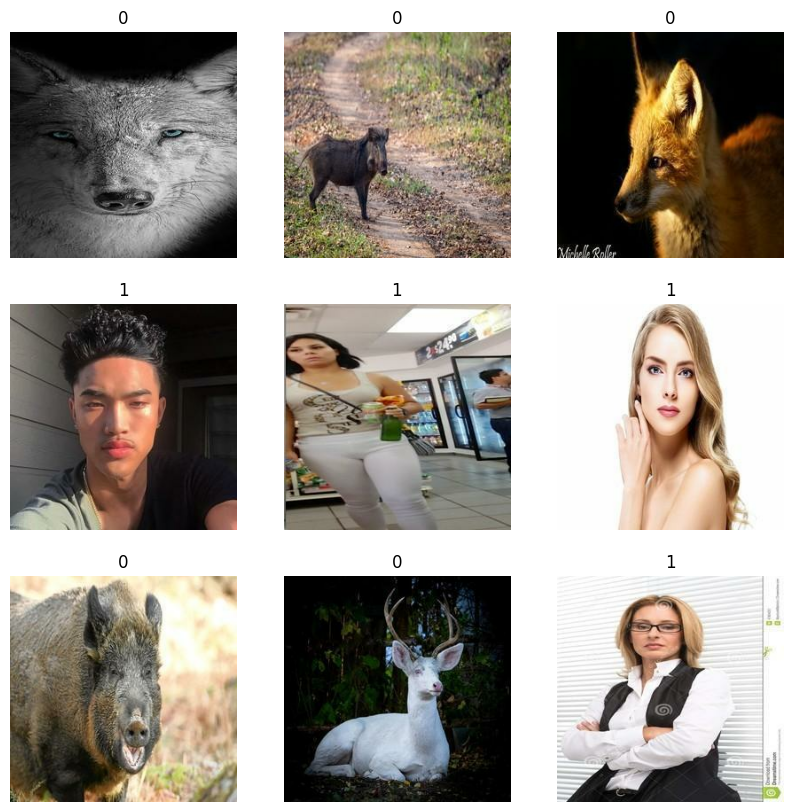

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## 2) Baselines

- Random guess accuracy? 50%

- Human-Level Performance accuracy? 100%

- Multilayer Perceptron accuracy? 65%

In [8]:
inputs = tf.keras.Input(shape=(256,256,3))
x = layers.Flatten()(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, output)

In [9]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 flatten (Flatten)           (None, 196608)            0         
                                                                 
 rescaling (Rescaling)       (None, 196608)            0         
                                                                 
 dense (Dense)               (None, 512)               100663808 
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 64)                16448     
                                                                 
 dropout (Dropout)           (None, 64)                0     

In [10]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

monitor_val_acc = EarlyStopping(monitor='val_loss', 
                                patience=5)

model_checkpoint = ModelCheckpoint('../models/best_model_dense.hdf5', save_best_only = True)

In [11]:
#h = model.fit(train_ds, epochs = 1000,
#                            batch_size = 32,
#                            validation_data=val_ds,
#                            callbacks=[monitor_val_acc, model_checkpoint])

In [12]:
'''
def loss_plotter(H):
    plt.figure()
    plt.plot(H.history['loss'])
    plt.plot(H.history['val_loss'])
    # Make it pretty
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    # YOUR CODE HERE #

loss_plotter(h)
'''

"\ndef loss_plotter(H):\n    plt.figure()\n    plt.plot(H.history['loss'])\n    plt.plot(H.history['val_loss'])\n    # Make it pretty\n    plt.title('Model loss')\n    plt.ylabel('Loss')\n    plt.xlabel('Epoch')\n    plt.legend(['Train', 'Test'])\n    plt.show()\n    # YOUR CODE HERE #\n\nloss_plotter(h)\n"

In [13]:
'''
def accuracy_plotter(H):
    # YOUR CODE HERE #
    plt.figure()
    plt.plot(H.history['accuracy'])
    plt.plot(H.history['val_accuracy'])
    # Make it pretty
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    
accuracy_plotter(h)
'''

"\ndef accuracy_plotter(H):\n    # YOUR CODE HERE #\n    plt.figure()\n    plt.plot(H.history['accuracy'])\n    plt.plot(H.history['val_accuracy'])\n    # Make it pretty\n    plt.title('Model accuracy')\n    plt.ylabel('accuracy')\n    plt.xlabel('Epoch')\n    plt.legend(['Train', 'Test'])\n    plt.show()\n    \naccuracy_plotter(h)\n"

In [14]:
'''
import seaborn as sns
from sklearn.metrics import confusion_matrix

predicted = np.round_(model.predict(X_test)) #TODO - test validation

conf_matrix = confusion_matrix(y_test, predicted)

ax = plt.subplot()
sns.heatmap(conf_matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['True', 'False']); ax.yaxis.set_ticklabels(['True', 'False']);

# Show the plot
plt.show()
'''


"\nimport seaborn as sns\nfrom sklearn.metrics import confusion_matrix\n\npredicted = np.round_(model.predict(X_test)) #TODO - test validation\n\nconf_matrix = confusion_matrix(y_test, predicted)\n\nax = plt.subplot()\nsns.heatmap(conf_matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation\n\n# labels, title and ticks\nax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); \nax.set_title('Confusion Matrix'); \nax.xaxis.set_ticklabels(['True', 'False']); ax.yaxis.set_ticklabels(['True', 'False']);\n\n# Show the plot\nplt.show()\n"

## 3) Preprocessing

Remove coruppted images,
resize all images to 256px by 256px

## 4) CNN architecture

In [5]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1)
    ]
)


In [29]:
inputs = tf.keras.Input(shape=(256,256,3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(256, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(128, kernel_size=3, activation='relu')(x)
#x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(64, 3, padding="same", activation='relu')(x)
#x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(32, 3, padding="same", activation='relu')(x)
#x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(16, 3, padding="same", activation='relu')(x)
#x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, output)

In [30]:
model.summary()

Model: "model_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 256, 256, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 256, 256, 3)       0         
                                                                 
 conv2d_8 (Conv2D)           (None, 254, 254, 256)     7168      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 85, 85, 256)      0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 83, 83, 128)       295040    
                                                          

## 5) CNN training

- Loss function

- Optimizer (with its hyper-parameters)

- Metrics

- Learning curves

In [31]:
model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

monitor_val_acc = tf.keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                   patience=5,
                                                   mode='auto',
                                                   restore_best_weights=True,
                                                   min_delta=0.005
                                                  )

model_checkpoint = tf.keras.callbacks.ModelCheckpoint('../models/cnn_400k_full_200323.hdf5', save_best_only = True)

In [32]:
h = model.fit(train_ds, validation_data = val_ds, epochs = 1000, callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000
36/36 [==============================] - 149s 4s/step - loss: 0.6928 - accuracy: 0.5393 - val_loss: 0.6866 - val_accuracy: 0.5980
Epoch 2/1000
36/36 [==============================] - 149s 4s/step - loss: 0.6546 - accuracy: 0.6161 - val_loss: 0.6061 - val_accuracy: 0.6531
Epoch 3/1000
36/36 [==============================] - 149s 4s/step - loss: 0.5731 - accuracy: 0.7112 - val_loss: 0.5132 - val_accuracy: 0.7347
Epoch 4/1000
36/36 [==============================] - 148s 4s/step - loss: 0.5351 - accuracy: 0.7277 - val_loss: 0.5293 - val_accuracy: 0.7102
Epoch 5/1000
36/36 [==============================] - 148s 4s/step - loss: 0.4835 - accuracy: 0.7487 - val_loss: 0.4159 - val_accuracy: 0.8122
Epoch 6/1000
36/36 [==============================] - 148s 4s/step - loss: 0.4230 - accuracy: 0.7976 - val_loss: 0.3959 - val_accuracy: 0.8224
Epoch 7/1000
36/36 [==============================] - 147s 4s/step - loss: 0.4386 - accuracy: 0.7923 - val_loss: 0.4151 - val_accuracy: 0.8122

## 6) Model performance

Metrics plots

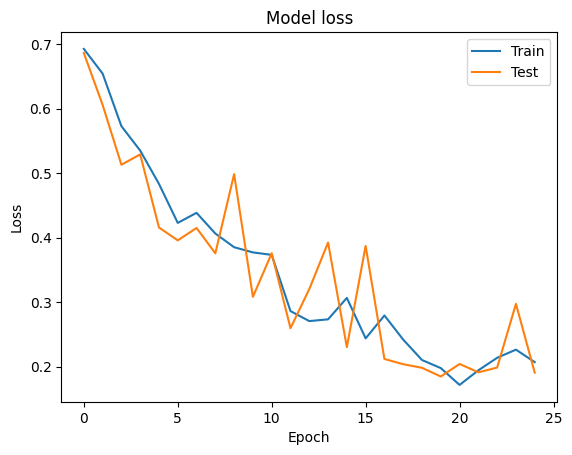

In [33]:
def loss_plotter(H):
    plt.figure()
    plt.plot(H.history['loss'])
    plt.plot(H.history['val_loss'])
    # Make it pretty
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    # YOUR CODE HERE #

loss_plotter(h)

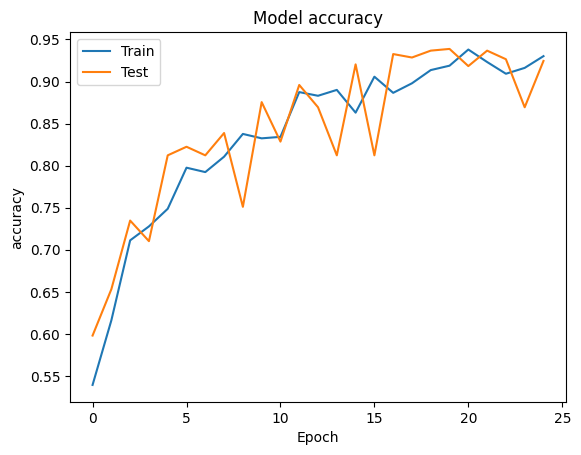

In [34]:
def accuracy_plotter(H):
    # YOUR CODE HERE #
    plt.figure()
    plt.plot(H.history['accuracy'])
    plt.plot(H.history['val_accuracy'])
    # Make it pretty
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'])
    plt.show()
    
accuracy_plotter(h)

## 7) Error analysis

Top error interpretation

In [35]:
def get_img_array(img_path, size):
    # `img` is a PIL image of size 299x299
    img = keras.preprocessing.image.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (299, 299, 3)
    array = keras.preprocessing.image.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size (1, 299, 299, 3)
    array = np.expand_dims(array, axis=0)
    return array


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    # Load the original image
    img = keras.preprocessing.image.load_img(img_path)
    img = keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = matplotlib.colormaps['jet'] #cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    display(Image(cam_path))


#### Heatmap for cnn

In [20]:
model = keras.models.load_model('../models/best_model_cnn_99k_full_170323_0.hdf5', compile=False)
model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

In [36]:
root_dir = "../testdata/"
sucess = 0
corrupt = 0
img_size = (256,256)
for filename in tqdm(glob.iglob(root_dir + '**/*.*', recursive=True)):
    try:
        im = ImagePIL.open(filename)
        imResize = im.resize(img_size, ImagePIL.ANTIALIAS)
        imResize.save(filename , 'JPEG')
        imResize.verify()
        sucess += 1
        
    except (IOError, SyntaxError) as e:
        os.remove(filename)
        corrupt += 1
        
print("sucessful: " + str(sucess))
print("coruppted: " + str(corrupt))

8it [00:00, 1050.64it/s]

sucessful: 8
coruppted: 0


Predicted: 0.09% human


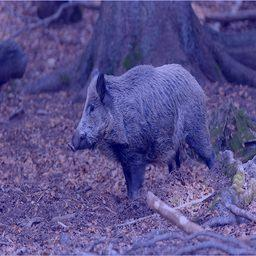

In [45]:
last_conv_layer_name = 'conv2d_12'
img_path = "../testdata/8.jpg"
#img_path = "../data/1 - animal/003142d190664bf5a27472bc058a9295.jpg"
img = keras.preprocessing.image.load_img(img_path)
#display(Image(img_path))

img_array = get_img_array(img_path, size=img_size)
# Print what the top predicted class is
preds = model.predict(img_array)
print(f"Predicted: {100 * float(preds[0]):.2f}% human")

# Generate class activation heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
save_and_display_gradcam(img_path, heatmap)

In [22]:
base_model = keras.applications.Xception(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(256, 256, 3),
    include_top=False)  # Do not include the ImageNet classifier at the top.
base_model.trainable = False
inputs = keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)  # Apply random data augmentation

# Pre-trained Xception weights requires that input be scaled
# from (0, 255) to a range of (-1., +1.), the rescaling layer
# outputs: `(inputs * scale) + offset`
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1)
x = scale_layer(x)
# We make sure that the base_model is running in inference mode here,
# by passing `training=False`. This is important for fine-tuning, as you will
# learn in a few paragraphs.
x = base_model(x, training=False)
# Convert features of shape `base_model.output_shape[1:]` to vectors
x = keras.layers.GlobalAveragePooling2D()(x)
# A Dense classifier with a single unit (binary classification)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1)(x)
model = keras.Model(inputs, outputs)


83683744/83683744 [==============================] - 0s 0us/step


In [23]:
model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

monitor_val_acc = tf.keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                   patience=5,
                                                   mode='auto',
                                                   restore_best_weights=True)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint('../models/best_model_transfer_cnn_full.hdf5', save_best_only = True)

In [ ]:
h = model.fit(train_ds, validation_data = val_ds, epochs = 1000, callbacks=[monitor_val_acc, model_checkpoint])

Epoch 1/1000


41/41 [==============================] - 564s 14s/step - loss: 0.6893 - accuracy: 0.8243 - val_loss: 0.0418 - val_accuracy: 0.9939
Epoch 2/1000
41/41 [==============================] - 547s 13s/step - loss: 0.0849 - accuracy: 0.9824 - val_loss: 0.0211 - val_accuracy: 0.9939
Epoch 3/1000
41/41 [==============================] - 551s 13s/step - loss: 0.0460 - accuracy: 0.9870 - val_loss: 0.0116 - val_accuracy: 1.0000
Epoch 4/1000
41/41 [==============================] - 538s 13s/step - loss: 0.0202 - accuracy: 0.9939 - val_loss: 0.0089 - val_accuracy: 1.0000
Epoch 5/1000
41/41 [==============================] - 538s 13s/step - loss: 0.0308 - accuracy: 0.9931 - val_loss: 0.0076 - val_accuracy: 1.0000
Epoch 6/1000
41/41 [==============================] - 537s 13s/step - loss: 0.0271 - accuracy: 0.9939 - val_loss: 0.0062 - val_accuracy: 1.0000
Epoch 7/1000
41/41 [==============================] - 538s 13s/step - loss: 0.0211 - accuracy: 0.9962 - val_loss: 0.0053 - val_accuracy: 1.0000
Epoch